In [2]:
# Criando dados fictícios
set.seed(123)  # Para reprodutibilidade

dados_casas <- data.frame(
  tamanho_m2 = c(85, 120, 95, 150, 110, 75, 140, 130, 100, 160),
  quartos = c(2, 3, 2, 4, 3, 2, 4, 3, 2, 4),
  idade_anos = c(15, 5, 20, 2, 10, 30, 3, 8, 12, 1),
  preco_mil = c(250, 380, 270, 500, 350, 200, 480, 420, 310, 550)
)

# Salvando como CSV
write.csv(dados_casas, "dados_casas.csv", row.names = FALSE)

# Visualizando os dados criados
print("Dados criados:")
print(dados_casas)

[1] "Dados criados:"
   tamanho_m2 quartos idade_anos preco_mil
1          85       2         15       250
2         120       3          5       380
3          95       2         20       270
4         150       4          2       500
5         110       3         10       350
6          75       2         30       200
7         140       4          3       480
8         130       3          8       420
9         100       2         12       310
10        160       4          1       550


In [3]:
# Instalando pacotes necessários (se necessário)
if(!require(ggplot2)) install.packages("ggplot2")

# Carregando bibliotecas
library(ggplot2)

# Lendo o arquivo CSV
casas <- read.csv("dados_casas.csv")

# Visualizando dados originais
print("Dados originais:")
print(casas)

# Removendo a terceira linha (linha específica)
casas <- casas[-3, ]  # Remove a linha 3 (idade_anos = 20, preco = 270)

# Removendo a coluna 'quartos' (considerada desnecessária)
casas$quartos <- NULL

# Visualizando dados após tratamento
print("Dados após remoção da 3ª linha e da coluna 'quartos':")
print(casas)

# Estatísticas descritivas
print("Resumo estatístico:")
summary(casas)

Loading required package: ggplot2



[1] "Dados originais:"
   tamanho_m2 quartos idade_anos preco_mil
1          85       2         15       250
2         120       3          5       380
3          95       2         20       270
4         150       4          2       500
5         110       3         10       350
6          75       2         30       200
7         140       4          3       480
8         130       3          8       420
9         100       2         12       310
10        160       4          1       550
[1] "Dados após remoção da 3ª linha e da coluna 'quartos':"
   tamanho_m2 idade_anos preco_mil
1          85         15       250
2         120          5       380
4         150          2       500
5         110         10       350
6          75         30       200
7         140          3       480
8         130          8       420
9         100         12       310
10        160          1       550
[1] "Resumo estatístico:"


   tamanho_m2      idade_anos       preco_mil    
 Min.   : 75.0   Min.   : 1.000   Min.   :200.0  
 1st Qu.:100.0   1st Qu.: 3.000   1st Qu.:310.0  
 Median :120.0   Median : 8.000   Median :380.0  
 Mean   :118.9   Mean   : 9.556   Mean   :382.2  
 3rd Qu.:140.0   3rd Qu.:12.000   3rd Qu.:480.0  
 Max.   :160.0   Max.   :30.000   Max.   :550.0  

In [4]:
# Criando modelo de regressão linear
# Preço = β0 + β1*tamanho_m2 + β2*idade_anos
modelo <- lm(preco_mil ~ tamanho_m2 + idade_anos, data = casas)

# Resumo do modelo
print("Resumo do modelo de regressão:")
summary(modelo)

# Coeficientes do modelo
print("Coeficientes:")
coeficientes <- coef(modelo)
print(coeficientes)

# Estimando preço para uma casa hipotética
# Exemplo: casa com 125m² e 7 anos de idade
casa_hipotetica <- data.frame(tamanho_m2 = 125, idade_anos = 7)
preco_estimado <- predict(modelo, casa_hipotetica)

print(paste("Preço estimado para casa de 125m² com 7 anos de idade:"))
print(paste("R$", round(preco_estimado, 2), "mil"))

[1] "Resumo do modelo de regressão:"



Call:
lm(formula = preco_mil ~ tamanho_m2 + idade_anos, data = casas)

Residuals:
   Min     1Q Median     3Q    Max 
-9.158 -6.131  2.105  2.442 12.268 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -72.4518    31.2333  -2.320   0.0595 .  
tamanho_m2    3.8708     0.2116  18.296 1.72e-06 ***
idade_anos   -0.5784     0.6811  -0.849   0.4284    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.647 on 6 degrees of freedom
Multiple R-squared:  0.9968,	Adjusted R-squared:  0.9957 
F-statistic: 937.1 on 2 and 6 DF,  p-value: 3.249e-08


[1] "Coeficientes:"
(Intercept)  tamanho_m2  idade_anos 
-72.4517751   3.8708466  -0.5783713 
[1] "Preço estimado para casa de 125m² com 7 anos de idade:"
[1] "R$ 407.36 mil"


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Using `size` aesthetic for lines was
deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


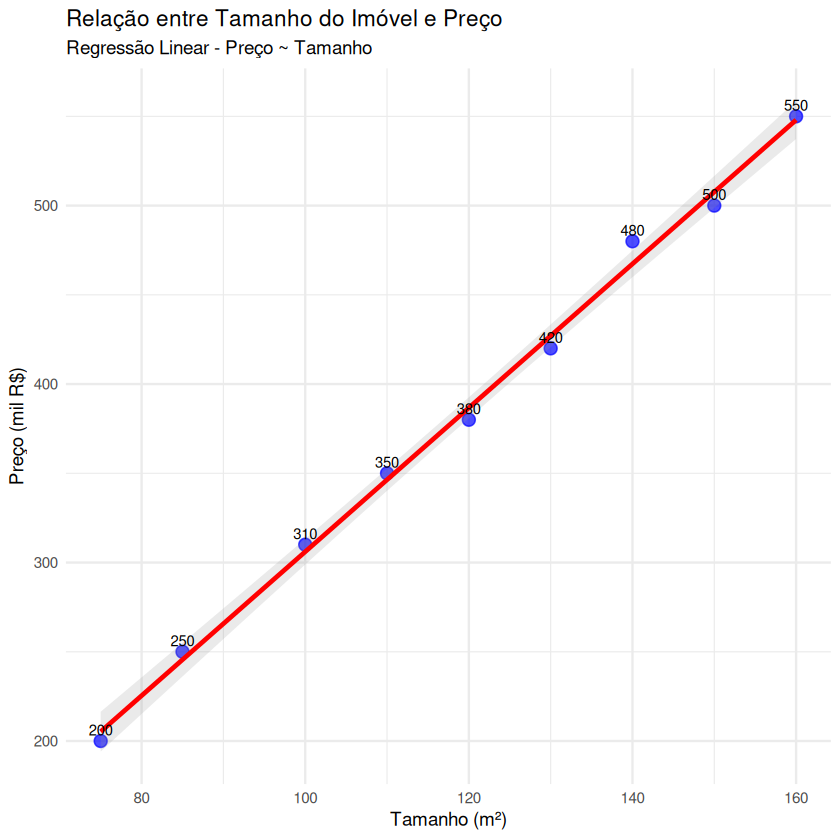

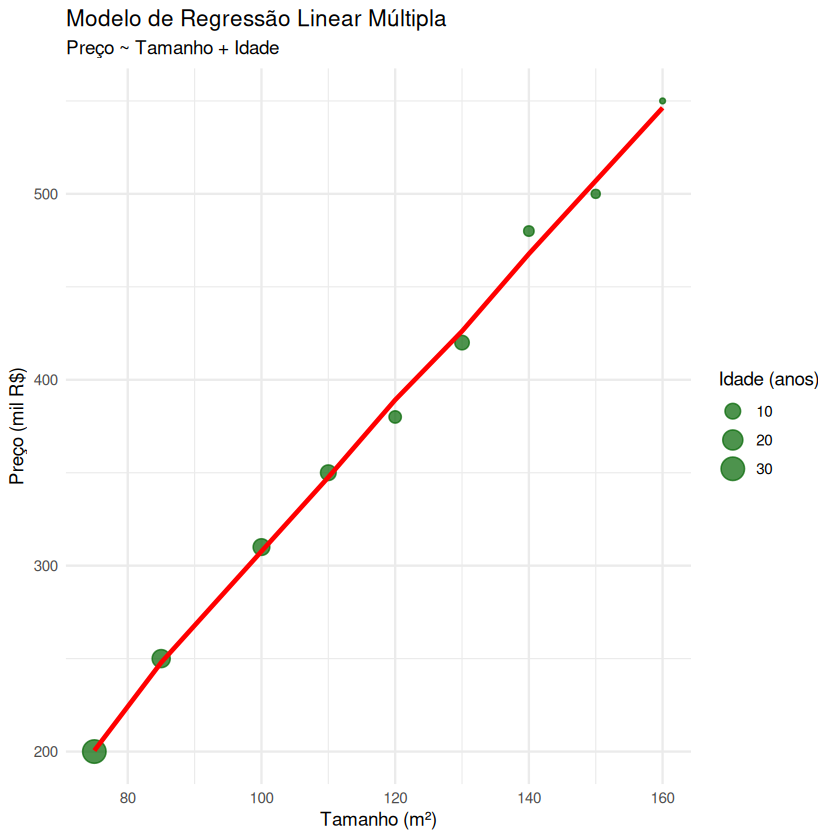

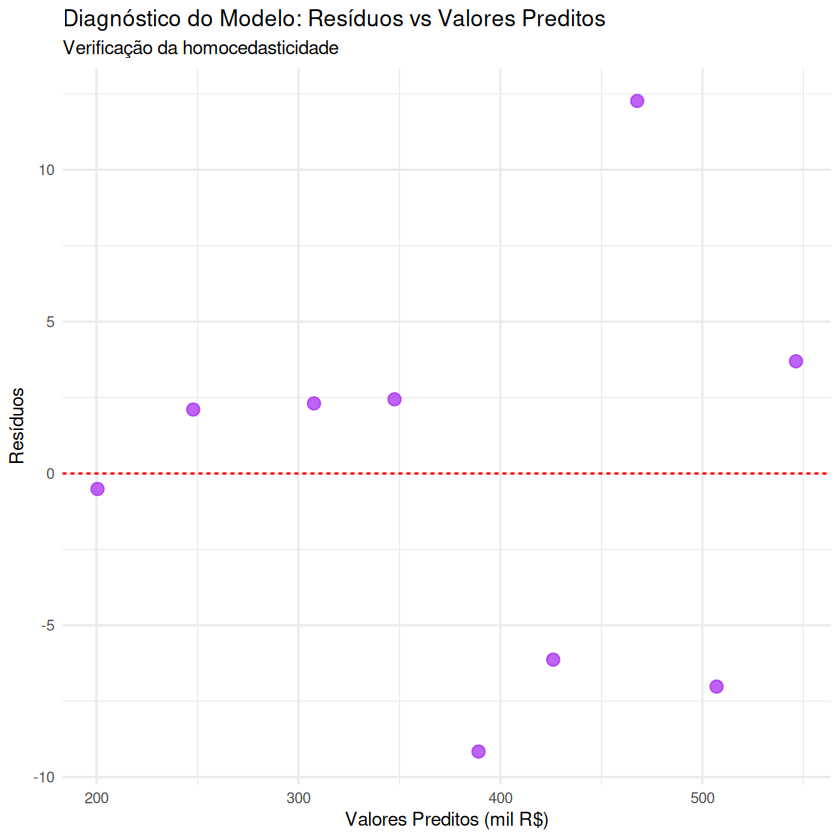

In [5]:
# Gráfico 1: Preço vs Tamanho (com linha de regressão)
ggplot(casas, aes(x = tamanho_m2, y = preco_mil)) +
  geom_point(size = 3, color = "blue", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "red", alpha = 0.2) +
  labs(title = "Relação entre Tamanho do Imóvel e Preço",
       subtitle = "Regressão Linear - Preço ~ Tamanho",
       x = "Tamanho (m²)",
       y = "Preço (mil R$)") +
  theme_minimal() +
  geom_text(aes(label = round(preco_mil, 0)), 
            vjust = -0.5, size = 3)

# Gráfico 2: Gráfico de dispersão 3D (preço vs tamanho e idade)
# Para melhor visualização da relação multivariada
casas$preco_predito <- predict(modelo)

ggplot(casas) +
  geom_point(aes(x = tamanho_m2, y = preco_mil, size = idade_anos), 
             color = "darkgreen", alpha = 0.7) +
  geom_line(aes(x = tamanho_m2, y = preco_predito), 
            color = "red", size = 1) +
  labs(title = "Modelo de Regressão Linear Múltipla",
       subtitle = "Preço ~ Tamanho + Idade",
       x = "Tamanho (m²)",
       y = "Preço (mil R$)",
       size = "Idade (anos)") +
  theme_minimal()

# Gráfico 3: Diagnóstico do modelo - Resíduos vs Valores Preditos
residuos <- resid(modelo)
preditos <- fitted(modelo)

ggplot(data.frame(preditos, residuos), aes(x = preditos, y = residuos)) +
  geom_point(size = 3, color = "purple", alpha = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(title = "Diagnóstico do Modelo: Resíduos vs Valores Preditos",
       subtitle = "Verificação da homocedasticidade",
       x = "Valores Preditos (mil R$)",
       y = "Resíduos") +
  theme_minimal()

[1] "Preços estimados para diferentes cenários:"
  tamanho_m2 idade_anos preco_estimado
1        100          5       311.7410
2        120         10       386.2661
3        140          8       464.8398
4        160          3       545.1486


`geom_smooth()` using formula = 'y ~ x'


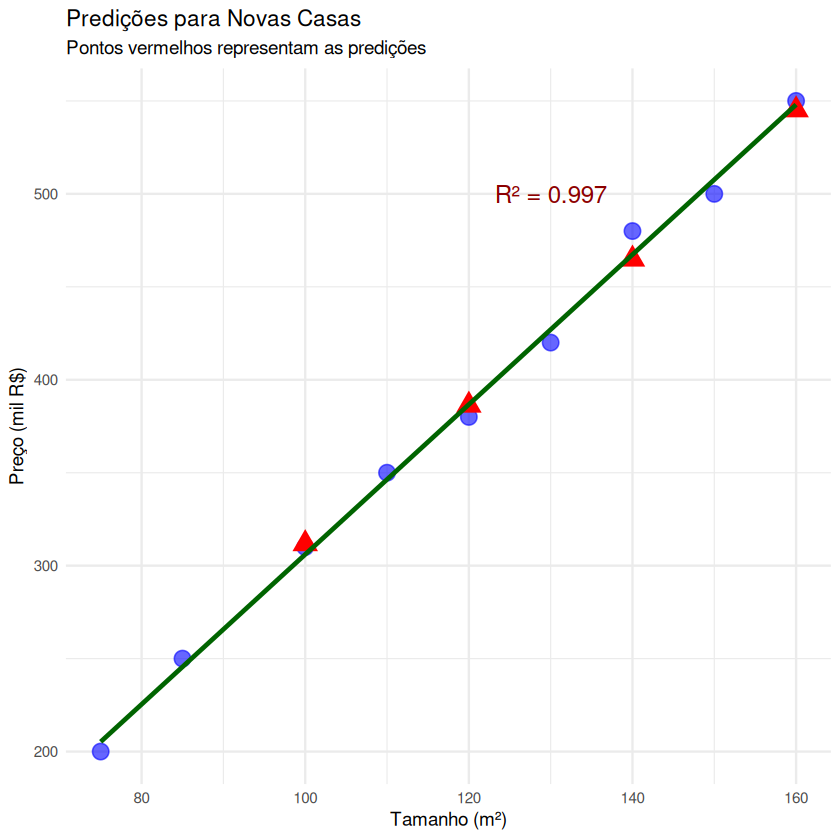

In [6]:
# Exemplo prático de predição para diferentes cenários
cenarios <- data.frame(
  tamanho_m2 = c(100, 120, 140, 160),
  idade_anos = c(5, 10, 8, 3)
)

cenarios$preco_estimado <- predict(modelo, cenarios)

print("Preços estimados para diferentes cenários:")
print(cenarios)

# Gráfico com predições
ggplot() +
  geom_point(data = casas, aes(x = tamanho_m2, y = preco_mil), 
             size = 4, color = "blue", alpha = 0.6) +
  geom_point(data = cenarios, aes(x = tamanho_m2, y = preco_estimado), 
             size = 5, color = "red", shape = 17) +
  geom_smooth(data = casas, aes(x = tamanho_m2, y = preco_mil), 
              method = "lm", se = FALSE, color = "darkgreen") +
  labs(title = "Predições para Novas Casas",
       subtitle = "Pontos vermelhos representam as predições",
       x = "Tamanho (m²)",
       y = "Preço (mil R$)") +
  theme_minimal() +
  annotate("text", x = 130, y = 500, 
           label = paste("R² =", round(summary(modelo)$r.squared, 3)), 
           color = "darkred", size = 5)